# 気象庁 解析雨量（1kmメッシュ）読み込みサンプル

気象庁の解析雨量GRIB2（`Z__C_RJTD_..._Prr60lv_ANAL_grib2.bin`）を読み込み、可視化するサンプルアプリ。

**背景**: 解析雨量GRIB2は気象庁ローカルの productDefinitionTemplate（第4節50008）と
独自のランレングス圧縮（第7節）を使用しており、`pygrib`（eccodes）では
`Unable to find template productDefinition` エラーとなり読み込めない。
そのため本ノートブックでは GRIB2 の第5節・第7節を自前でパースする。

手法参考: https://qiita.com/vpcf/items/b680f504cfe8b6a64222

実行環境: `conda activate met_env_310`（pygrib比較用に使用。本体のパースにpygribは不要）

対応スクリプト（CLI版）: `JMA_AnalysisRain.py`


## 1. インポート

In [1]:
import struct
from itertools import repeat
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs


## 2. サンプルファイルの確認

`data/jmara/` に解析雨量GRIB2ファイルを手動配置しておく（自動ダウンロード非対応）。

動作確認用サンプルは気象庁公式サンプルページから入手可能:
https://www.data.jma.go.jp/developer/gpv_sample/kotan_kaiseki.zip


In [2]:
DATA_DIR = Path("./data/jmara")
SAMPLE_FILE = DATA_DIR / "Z__C_RJTD_20210817090000_SRF_GPV_Ggis1km_Prr60lv_ANAL_grib2.bin"

assert SAMPLE_FILE.exists(), f"サンプルファイルが見つかりません: {SAMPLE_FILE}"
print(f"ファイル: {SAMPLE_FILE.name}")
print(f"サイズ  : {SAMPLE_FILE.stat().st_size / 1024:.1f} KB")


ファイル: Z__C_RJTD_20210817090000_SRF_GPV_Ggis1km_Prr60lv_ANAL_grib2.bin
サイズ  : 324.7 KB


## 3. pygribで読めるか確認（比較用）

pygrib（eccodes）は気象庁ローカルテンプレートに未対応のため、エラーになることを確認する。


In [3]:
import pygrib

grbs = pygrib.open(str(SAMPLE_FILE))
msgs = list(grbs)
grbs.close()
print(f"pygrib.open() で開けたメッセージ数: {len(msgs)}（ただしECCODES ERRORログに注目 → テンプレート未対応）")

# メッセージは開けても、ローカルテンプレート未対応のため中身は正しく読めない
try:
    grb = msgs[0]
    name = grb.shortName
    print(f"shortName: {name}")
except Exception as e:
    print(f"属性取得でエラー: {type(e).__name__}: {e}")


pygrib.open() で開けたメッセージ数: 1（ただしECCODES ERRORログに注目 → テンプレート未対応）
属性取得でエラー: RuntimeError: Key/value not found


ECCODES ERROR   :  Unable to find template productDefinition from grib2/local/rjtd/template.4.50008.def 
ECCODES ERROR   :  grib_handle_new_from_message_: No final 7777 in message!
ECCODES ERROR   :  Unable to find template productDefinition from grib2/local/rjtd/template.4.50008.def 
ECCODES ERROR   :  grib_handle_new_from_message_: No final 7777 in message!
ECCODES ERROR   :  Unable to find template productDefinition from grib2/local/rjtd/template.4.50008.def 
ECCODES ERROR   :  grib_handle_new_from_message_: No final 7777 in message!
ECCODES ERROR   :  Unable to find template productDefinition from grib2/local/rjtd/template.4.50008.def 
ECCODES ERROR   :  grib_handle_new_from_message_: No final 7777 in message!


## 4. 自前GRIB2パーサー

- 第5節: レベル値 → 降水強度（mm/h、10倍値）の対応テーブルを取得
- 第7節: ランレングス圧縮されたレベル値を展開
- 展開したレベル値をテーブルで変換し、1/10倍して mm/h を得る

格子仕様: 3360行 × 2560列、全国合成1kmメッシュ（118-150°E, 20-48°N）


In [4]:
GRID_SHAPE = (3360, 2560)
GRID_LON_RANGE = (118.0, 150.0)
GRID_LAT_RANGE = (48.0, 20.0)  # 北→南


def set_table(section5):
    max_level = struct.unpack_from('>H', section5, 15)[0]
    table = (
        -10,
        *struct.unpack_from('>' + str(max_level) + 'H', section5, 18)
    )
    return np.array(table, dtype=np.int16)


def decode_runlength(code, hi_level):
    level = 0
    for raw in code:
        if raw <= hi_level:
            level = raw
            pwr = 0
            yield level
        else:
            length = (0xFF - hi_level) ** pwr * (raw - (hi_level + 1))
            pwr += 1
            yield from repeat(level, length)


def load_jmara_grib2(path):
    with open(path, 'rb') as f:
        binary = f.read()

    len_ = {'sec0': 16, 'sec1': 21, 'sec3': 72, 'sec4': 82, 'sec6': 6}

    end4 = len_['sec0'] + len_['sec1'] + len_['sec3'] + len_['sec4'] - 1
    len_['sec5'] = struct.unpack_from('>I', binary, end4 + 1)[0]
    section5 = binary[end4:(end4 + len_['sec5'] + 1)]

    end6 = end4 + len_['sec5'] + len_['sec6']
    len_['sec7'] = struct.unpack_from('>I', binary, end6 + 1)[0]
    section7 = binary[end6:(end6 + len_['sec7'] + 1)]

    highest_level = struct.unpack_from('>H', section5, 13)[0]
    level_table = set_table(section5)
    decoded = np.fromiter(
        decode_runlength(section7[6:], highest_level), dtype=np.int16
    ).reshape(GRID_SHAPE)

    return level_table[decoded]


def jmara_grid():
    ny, nx = GRID_SHAPE
    lon = np.linspace(*GRID_LON_RANGE, nx, endpoint=False) + 1 / 80 / 2
    lat = np.linspace(*GRID_LAT_RANGE, ny, endpoint=False) - 1 / 80 / 1.5 / 2
    return lon, lat


## 5. データ読み込み

In [5]:
rain = load_jmara_grib2(SAMPLE_FILE) / 10.0  # 0.1mm/h単位 -> mm/h
rain_masked = np.where(rain < 0, np.nan, rain)  # 欠測（レベル0未満）を除外

print("shape:", rain.shape)
print("値域 (欠測含む):", rain.min(), "〜", rain.max(), "mm/h")
valid = rain_masked[~np.isnan(rain_masked)]
print(f"降水セル数(>0mm/h): {int((valid > 0).sum())} / {valid.size}")
print(f"降水セル数(>=10mm/h): {int((valid >= 10).sum())}")
print(f"最大降水強度: {valid.max():.1f} mm/h")


shape: (3360, 2560)
値域 (欠測含む): -1.0 〜 100.0 mm/h
降水セル数(>0mm/h): 734157 / 2293165
降水セル数(>=10mm/h): 36126
最大降水強度: 100.0 mm/h


## 6. 可視化

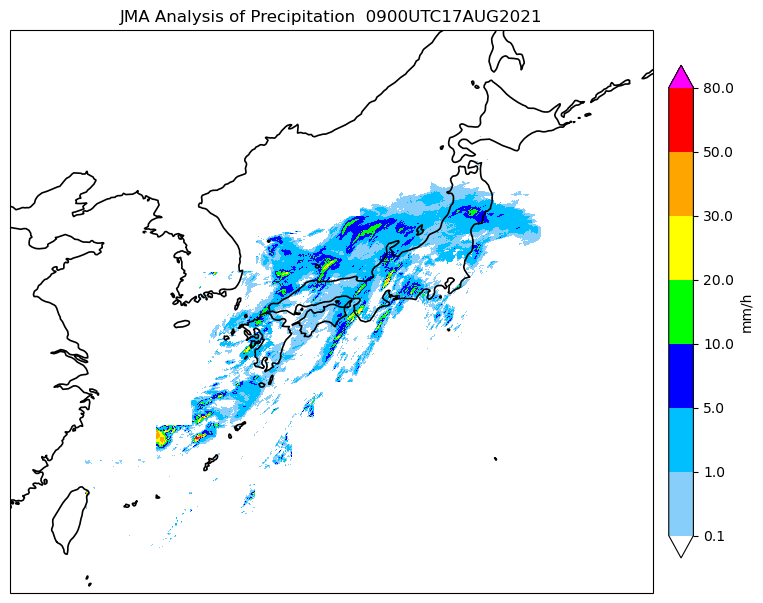

In [6]:
lon, lat = jmara_grid()

levels = [0.1, 1, 5, 10, 20, 30, 50, 80]
colors = ['lightskyblue', 'deepskyblue', 'blue', 'lime', 'yellow', 'orange', 'red']
cmap = mcolors.ListedColormap(colors)
cmap.set_under('white')
cmap.set_over('magenta')
norm = mcolors.BoundaryNorm(levels, cmap.N)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent([*GRID_LON_RANGE, GRID_LAT_RANGE[1], GRID_LAT_RANGE[0]], proj)

mesh = ax.pcolormesh(lon, lat, rain_masked, cmap=cmap, norm=norm, transform=proj, shading='auto')
ax.coastlines(resolution='50m', linewidth=1.2)
cb = fig.colorbar(mesh, ax=ax, orientation='vertical', extend='both', shrink=0.8, pad=0.02)
cb.set_label('mm/h')
ax.set_title('JMA Analysis of Precipitation  0900UTC17AUG2021')
plt.show()


## まとめ

- 解析雨量GRIB2は `pygrib` では読めないが、第5節・第7節を自前パースすれば `numpy` 配列として扱える
- 実運用時（複数時刻・自動実行）は `JMA_AnalysisRain.py` を使用する

```bash
conda activate met_env_310
python JMA_AnalysisRain.py 202108170900
```
